# Module 11 — Deep Learning on Images

*How a network learns to see.*

In the 1990s the US Postal Service had a very concrete problem: machines needed to read handwritten ZIP codes on envelopes. The **MNIST** dataset grew out of that effort — 70,000 handwritten digits collected from US Census Bureau employees and American high-school students, scanned, centered, and shrunk to tiny 28×28 grayscale images. Yann LeCun and colleagues turned it into the standard benchmark for machine vision, and it has been used to test essentially every image-recognition idea since.

MNIST is the **fruit fly of deep learning** — a model organism. Like *Drosophila*, it's small, cheap, and fast to work with, yet everything we discover on it (convolution, pooling, feature maps, confusion matrices) transfers directly to the "mouse work": real medical images, like the malaria-infected blood cells waiting in the capstone project.

One sentence of recap from Module 10, because it's all we need: a network is trained by repeating the loop **forward → loss → `zero_grad()` → `backward()` → `step()`** until the loss stops falling. That loop will not change in this module — only the *shape of the network* changes. Run each cell in order, predicting outputs first; every non-obvious line has a `#` comment.

In [1]:
import numpy as np                # arrays (Module 01)
import matplotlib.pyplot as plt   # drawing plots
import seaborn as sns             # nicer-looking plots
import torch                      # tensors + autograd (Module 10)
import torch.nn as nn             # neural-network building blocks (Module 10)

sns.set_theme(style="whitegrid", palette="colorblind")

# Fix the random seeds so shuffles and starting weights are the same every run.
torch.manual_seed(42)
np.random.seed(42)

## 1. Load MNIST and look at it

The dataset comes pre-split into a **train** part (60,000 images the models learn from) and a **test** part (10,000 images kept aside to measure honest accuracy — the same train/test discipline as always). Each example is a tiny picture plus its label, the digit 0–9 that a human says it is.

In [2]:
from datasets import load_dataset   # the HuggingFace downloader (same as every module)

mnist = load_dataset("ylecun/mnist")   # downloads once, then loads from cache in seconds

print(mnist)   # shows the two splits and how many images each contains

# One example is a dictionary: an 'image' (a small picture object) and a 'label' (0-9).
example = mnist["train"][0]
print(example["image"], "-> label:", example["label"])

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})
<PIL.PngImagePlugin.PngImageFile image mode=L size=28x28 at 0x121684AD0> -> label: 5


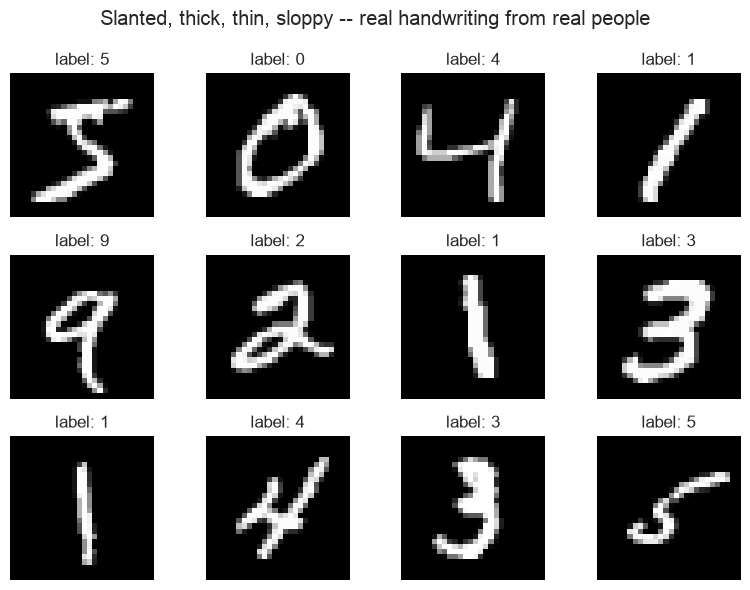

In [3]:
# Rule number one never changes: LOOK at the data first. Images are no exception.
fig, axes = plt.subplots(3, 4, figsize=(8, 6))   # a 3x4 grid of small plots

for k in range(12):
    row = k // 4              # // is integer division: k=0..3 -> row 0, k=4..7 -> row 1, ...
    col = k % 4               # % is the remainder:      k=0..3 -> cols 0,1,2,3, then repeat
    example = mnist["train"][k]
    # imshow draws a grid of numbers as a picture; cmap='gray' = black-to-white.
    axes[row, col].imshow(example["image"], cmap="gray")
    axes[row, col].set_title(f"label: {example['label']}")
    axes[row, col].axis("off")   # hide the axis ticks -- they mean nothing on an image

fig.suptitle("Slanted, thick, thin, sloppy -- real handwriting from real people")
plt.tight_layout()
plt.show()

## 2. A digit is just numbers

Your retina doesn't send "a five" to your brain — it sends a grid of light intensities, and the *seeing* happens downstream. A grayscale image is the same thing: a grid of numbers, one per **pixel** (picture element). In MNIST, 0 means black background and 255 means the brightest white ink.

Let's dissect one specimen. `np.array()` converts the picture object into a plain NumPy array — after that, everything from Module 01 applies.

In [4]:
# Convert the first training image into a plain 28x28 NumPy array of numbers.
digit = np.array(mnist["train"][0]["image"])
label = mnist["train"][0]["label"]

print("shape:", digit.shape)     # (28, 28): 28 rows x 28 columns of pixels
print("smallest pixel:", digit.min(), "  largest pixel:", digit.max())
print()

# Print the middle of the grid. [4:24:2, 4:24:2] is Module 01 slicing:
# rows 4 to 23 stepping by 2, same for columns -- a downsampled 10x10 view
# that fits on screen. Squint and you can already see the 5 in the numbers!
print(digit[4:24:2, 4:24:2])

shape: (28, 28)
smallest pixel: 0   largest pixel: 255

[[  0   0   0   0   0   0   0   0   0   0]
 [  0   0  30  94 170 253 253 225 253 195]
 [  0   0 219 253 253 198 247   0   0   0]
 [  0   0   0   1 253   0   0   0   0   0]
 [  0   0   0   0 190  70   0   0   0   0]
 [  0   0   0   0   0 240 253  25   0   0]
 [  0   0   0   0   0   0  93 253   0   0]
 [  0   0   0   0   0  46 183 253   2   0]
 [  0   0   0  24 221 253 253  78   0   0]
 [  0  18 219 253 253  80   0   0   0   0]]


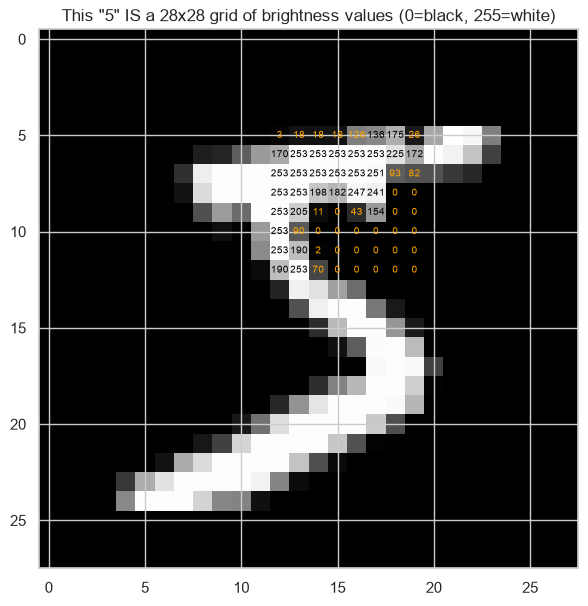

In [5]:
# Same image, drawn -- with the actual numeric values written inside one patch
# of pixels, so you can see that the picture and the numbers are the same thing.
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(digit, cmap="gray")

for i in range(5, 13):           # rows 5..12 of the image
    for j in range(12, 20):      # columns 12..19 -- a patch crossing an ink edge
        value = digit[i, j]
        if value < 128:
            text_color = "orange"    # readable on dark pixels
        else:
            text_color = "black"     # readable on bright pixels
        # ax.text(x, y, ...) writes text at that spot; for images x=column, y=row.
        ax.text(j, i, str(value), ha="center", va="center", fontsize=7, color=text_color)

ax.set_title(f'This "{label}" IS a 28x28 grid of brightness values (0=black, 255=white)')
plt.show()

Now we prepare the data for PyTorch. Two decisions worth spelling out:

- **Subsampling.** We take 20,000 of the 60,000 training images so every experiment in this notebook runs in seconds on a laptop.
- **Normalization.** We divide by 255 so pixel values run from 0 to 1. Networks train much better when all inputs are small, comparable numbers — the same reason we scaled features before clustering in Module 08.

In [6]:
# 20,000 of the 60,000 training images keeps every run laptop-fast.
# With the full 60,000 and more epochs you'd gain roughly another 1% accuracy.
n_train = 20000

train_images = []
train_labels = []
for i in range(n_train):
    example = mnist["train"][i]
    train_images.append(np.array(example["image"]))   # picture object -> 28x28 array
    train_labels.append(example["label"])

test_images = []
test_labels = []
for i in range(len(mnist["test"])):                   # keep ALL 10,000 test images
    example = mnist["test"][i]
    test_images.append(np.array(example["image"]))
    test_labels.append(example["label"])

# np.stack piles a list of 28x28 arrays into one big 3-D array: (n, 28, 28).
X_train = np.stack(train_images)
X_test = np.stack(test_images)
y_train = np.array(train_labels)
y_test = np.array(test_labels)

print("X_train:", X_train.shape, "  X_test:", X_test.shape)

X_train: (20000, 28, 28)   X_test: (10000, 28, 28)


In [7]:
# Wrap the arrays as PyTorch tensors (Module 10: NumPy arrays that remember
# their math), normalizing 0..255 down to 0..1 as we go.
X_train_t = torch.tensor(X_train, dtype=torch.float32) / 255.0
X_test_t = torch.tensor(X_test, dtype=torch.float32) / 255.0
y_train_t = torch.tensor(y_train, dtype=torch.long)   # class labels must be integers
y_test_t = torch.tensor(y_test, dtype=torch.long)

# .item() pulls a single number out of a tensor so it prints cleanly.
print("pixel values now run from", X_train_t.min().item(), "to", X_train_t.max().item())

pixel values now run from 0.0 to 1.0


## 3. Baseline: flatten + MLP

Module 10's network (an **MLP** — multi-layer perceptron, the plain stack of linear layers and ReLUs) expects each example to be a flat row of numbers, like a row in the penguin table. So the obvious move: unroll each 28×28 grid into one row of 784 numbers, and train exactly the network we already know.

The output layer has **10 neurons — one score per digit**. Whichever digit's score is highest is the network's prediction. That's how multi-class classification works in PyTorch, and `CrossEntropyLoss` is the matching loss function (it rewards putting the highest score on the true label).

In [8]:
# .reshape(n, 784) unrolls each 28x28 grid into one flat row, row by row --
# like reading a crossword grid left-to-right, top-to-bottom, into one long line.
X_train_flat = X_train_t.reshape(len(X_train_t), 784)
X_test_flat = X_test_t.reshape(len(X_test_t), 784)
print("flattened:", X_train_flat.shape)

# The same style of network as Module 10, sized for this input:
mlp = nn.Sequential(
    nn.Linear(784, 128),   # 784 pixel columns -> 128 hidden neurons
    nn.ReLU(),             # keep positive signals, zero out negative ones
    nn.Linear(128, 10),    # 128 hidden neurons -> 10 digit scores
)
print(mlp)

flattened: torch.Size([20000, 784])
Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=10, bias=True)
)


In [9]:
def accuracy(model, X, y):
    """Fraction of examples the model labels correctly."""
    with torch.no_grad():                    # just predicting -- no gradients needed
        scores = model(X)                    # one row of 10 scores per image
        predictions = scores.argmax(dim=1)   # argmax = position of the highest score
        correct = (predictions == y).sum().item()
    return correct / len(y)


def train_model(model, X, y, n_epochs, batch_size=128):
    """Module 10's training loop, unchanged: forward -> loss -> zero_grad -> backward -> step."""
    loss_fn = nn.CrossEntropyLoss()          # the standard loss for classification
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(n_epochs):            # one epoch = one full pass over the data
        shuffled = torch.randperm(len(X))    # the row numbers 0..n-1 in random order
        for start in range(0, len(X), batch_size):
            batch = shuffled[start:start + batch_size]   # the next 128 row numbers
            scores = model(X[batch])                     # forward: predict scores
            loss = loss_fn(scores, y[batch])             # how wrong were we?
            optimizer.zero_grad()                        # clear the old gradients
            loss.backward()                              # compute the new gradients
            optimizer.step()                             # nudge every weight a little
        # :.3f in an f-string means 'show 3 decimal places'.
        print(f"  epoch {epoch + 1}: last batch loss = {loss.item():.3f}")

In [10]:
# 10 quick epochs (~1 second) -- on our 20,000-image diet the network needs
# a few passes to settle; training on the full 60,000 would add roughly 1% more.
print("training the MLP...")
train_model(mlp, X_train_flat, y_train_t, n_epochs=10)

mlp_accuracy = accuracy(mlp, X_test_flat, y_test_t)
print(f"MLP test accuracy: {mlp_accuracy:.3f}")

training the MLP...


  epoch 1: last batch loss = 0.383
  epoch 2: last batch loss = 0.325
  epoch 3: last batch loss = 0.273
  epoch 4: last batch loss = 0.178
  epoch 5: last batch loss = 0.116


  epoch 6: last batch loss = 0.163
  epoch 7: last batch loss = 0.300
  epoch 8: last batch loss = 0.057
  epoch 9: last batch loss = 0.091
  epoch 10: last batch loss = 0.049


MLP test accuracy: 0.959


## 4. The MLP's blind spot

About 96% on unseen digits — a network that reads handwriting. Before celebrating, remember what we fed it: 784 **unrelated columns**. The MLP has no idea that column 294 and column 322 are vertical neighbors in the picture; they might as well be bill length and body mass. It never learned what a *shape* is — it learned "when these particular columns are bright, the label tends to be 5."

Here's the experiment that exposes this. `np.roll(images, 3, axis=2)` slides every image 3 pixels to the right (`axis=2` is the column axis of our `(10000, 28, 28)` array; pixels that fall off the right edge wrap around to the left). A human doesn't even notice a 3-pixel shift. But now *every pixel is in a different column*…

In [11]:
# Shift EVERY test image 3 pixels to the right.
X_test_shifted = np.roll(X_test, 3, axis=2)

# Flatten + normalize the shifted images exactly like the originals.
X_test_shifted_flat = torch.tensor(X_test_shifted, dtype=torch.float32).reshape(10000, 784) / 255.0

acc_original = accuracy(mlp, X_test_flat, y_test_t)
acc_shifted = accuracy(mlp, X_test_shifted_flat, y_test_t)
print(f"MLP accuracy, original test digits: {acc_original:.3f}")
print(f"MLP accuracy, shifted 3px right:    {acc_shifted:.3f}   <- collapse!")

MLP accuracy, original test digits: 0.959
MLP accuracy, shifted 3px right:    0.471   <- collapse!


first flipped digit is test image number 2


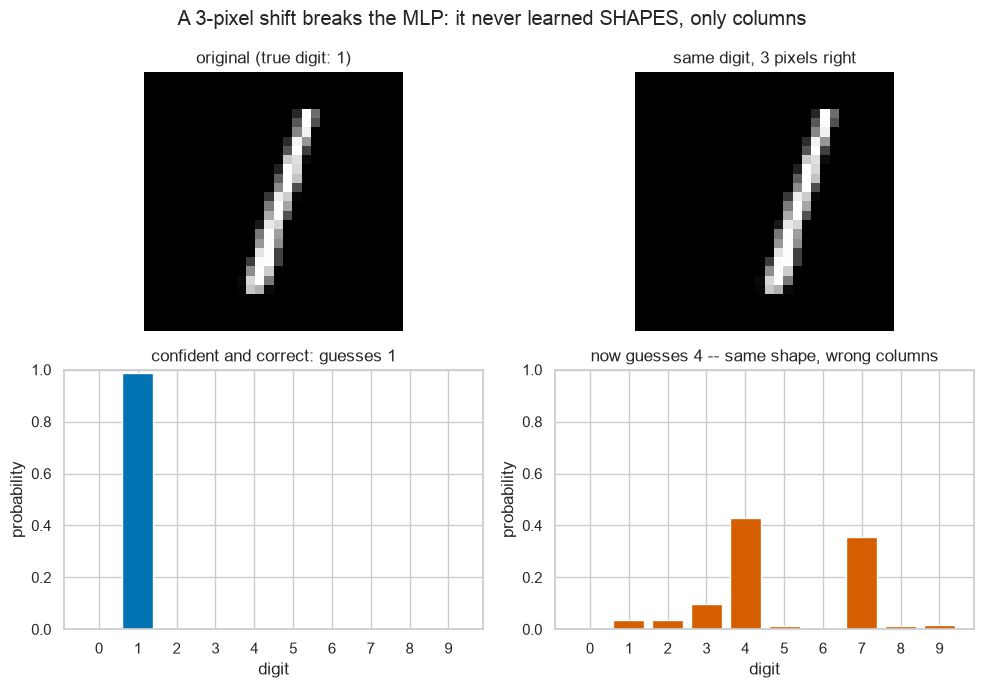

In [12]:
def mlp_probabilities(image_array):
    """The MLP's 10 probabilities (one per digit) for a single 0..255 image."""
    x = torch.tensor(image_array, dtype=torch.float32) / 255.0   # same normalization
    x = x.reshape(1, 784)               # a batch of 1 image, 784 columns
    with torch.no_grad():
        scores = mlp(x)
        # softmax converts 10 raw scores into 10 probabilities that sum to 1 --
        # 'how confident is the network in each digit?'
        probabilities = torch.softmax(scores, dim=1)
    return probabilities[0].numpy()     # back to a plain NumPy array of 10 numbers

# Find a digit the MLP gets right normally but WRONG once shifted.
flip = None
for i in range(len(X_test)):
    probs_original = mlp_probabilities(X_test[i])
    probs_shifted = mlp_probabilities(X_test_shifted[i])
    if probs_original.argmax() == y_test[i] and probs_shifted.argmax() != y_test[i]:
        flip = i
        break                            # stop at the first example that flips
print("first flipped digit is test image number", flip)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes[0, 0].imshow(X_test[flip], cmap="gray")
axes[0, 0].set_title(f"original (true digit: {y_test[flip]})")
axes[0, 0].axis("off")
axes[0, 1].imshow(X_test_shifted[flip], cmap="gray")
axes[0, 1].set_title("same digit, 3 pixels right")
axes[0, 1].axis("off")

# Bar charts of the 10 probabilities, before and after the shift.
axes[1, 0].bar(range(10), probs_original, color="#0173B2")
axes[1, 0].set_title(f"confident and correct: guesses {probs_original.argmax()}")
axes[1, 1].bar(range(10), probs_shifted, color="#D55E00")
axes[1, 1].set_title(f"now guesses {probs_shifted.argmax()} -- same shape, wrong columns")
for ax in [axes[1, 0], axes[1, 1]]:
    ax.set_xticks(range(10))             # one tick per digit 0-9
    ax.set_xlabel("digit")
    ax.set_ylabel("probability")
    ax.set_ylim(0, 1)

fig.suptitle("A 3-pixel shift breaks the MLP: it never learned SHAPES, only columns")
plt.tight_layout()
plt.show()

## 5. Convolution by hand: a motif scanner

Here is the fix, and it will feel familiar. A **restriction enzyme** like EcoRI doesn't have a separate rule for every position in the genome — it has *one* recognition motif (GAATTC) and slides along the DNA, cutting wherever that motif appears. One small pattern detector, applied everywhere.

A **convolution filter** is exactly that, for images: a tiny grid of weights — ours is 3×3 — that slides across the picture. At each position it multiplies its 9 weights by the 9 pixels underneath, adds them up, and writes down one number: *"how strongly does my motif appear right here?"* The grid of all those numbers is called a **feature map** — a picture of *where the motif was found*, like a gel lane showing where the enzyme cut.

No PyTorch yet. We'll do one convolution with plain Python loops, so you can see there is nothing inside it but multiply-and-add. Our hand-made filter has positive weights on its left column and negative on its right, so it responds strongly where bright pixels sit immediately left of dark ones — a **vertical edge detector**.

image: (28, 28) -> feature map: (26, 26)


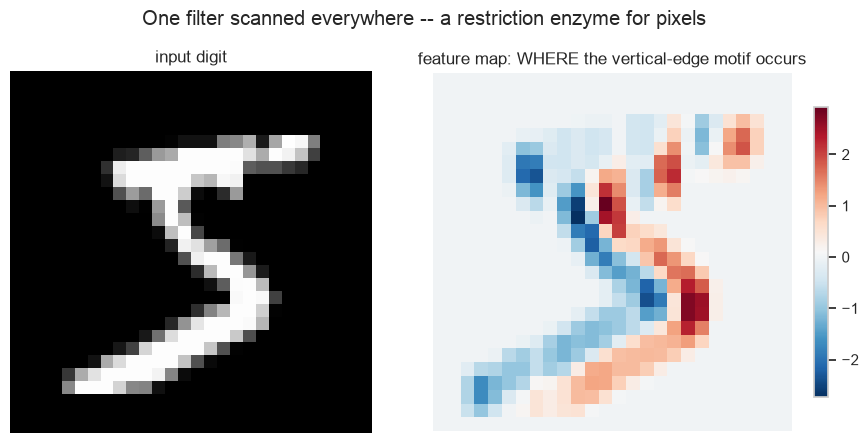

In [13]:
# The motif: bright-on-the-left, dark-on-the-right (a vertical edge).
edge_filter = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1],
])


def convolve(image, filt):
    """Slide a 3x3 filter over an image, plain loops, no tricks."""
    n_rows = image.shape[0] - 2     # a 3x3 window fits in 26 positions along a 28-pixel side
    n_cols = image.shape[1] - 2
    result = np.zeros((n_rows, n_cols))
    for i in range(n_rows):
        for j in range(n_cols):
            patch = image[i:i + 3, j:j + 3]        # the 3x3 patch under the filter
            result[i, j] = np.sum(patch * filt)    # multiply cell-by-cell, add up
    return result


image = X_train[0] / 255.0                  # our familiar 5, normalized to 0..1
feature_map = convolve(image, edge_filter)
print("image:", image.shape, "-> feature map:", feature_map.shape)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.5))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("input digit")
axes[0].axis("off")
# RdBu_r: red = strong positive response, blue = strong negative, white = no motif.
im = axes[1].imshow(feature_map, cmap="RdBu_r")
axes[1].set_title("feature map: WHERE the vertical-edge motif occurs")
axes[1].axis("off")
fig.colorbar(im, ax=axes[1], shrink=0.8)     # the color scale bar
fig.suptitle("One filter scanned everywhere -- a restriction enzyme for pixels")
plt.tight_layout()
plt.show()

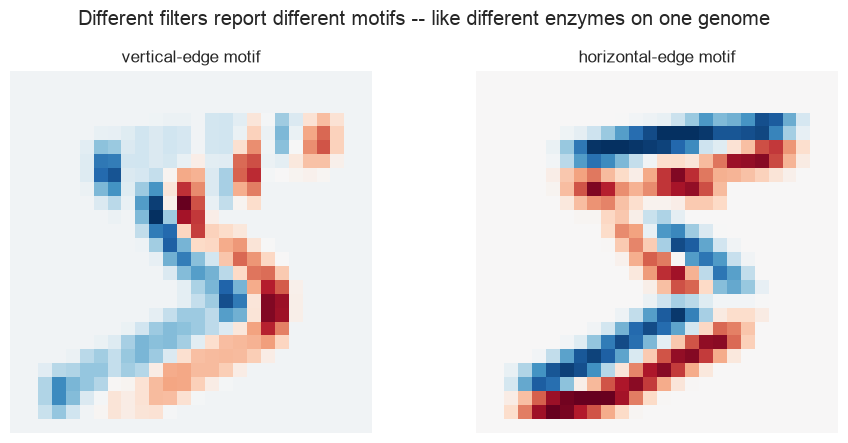

In [14]:
# A different filter = a different motif. .T transposes the filter (swaps rows
# and columns), turning our vertical-edge detector into a horizontal-edge one.
horizontal_map = convolve(image, edge_filter.T)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.5))
axes[0].imshow(feature_map, cmap="RdBu_r")
axes[0].set_title("vertical-edge motif")
axes[0].axis("off")
axes[1].imshow(horizontal_map, cmap="RdBu_r")
axes[1].set_title("horizontal-edge motif")
axes[1].axis("off")
fig.suptitle("Different filters report different motifs -- like different enzymes on one genome")
plt.tight_layout()
plt.show()

## 6. Pooling: shrink, but keep the strongest signal

A feature map answers "where exactly is the motif?" — often in more detail than we need. **Max pooling** cuts the map into 2×2 blocks and keeps only the *largest* value in each block. The map halves in width and height, and the surviving information is "there was a strong motif response *somewhere in this region*" — like summarizing a gel by the strongest band in each region of a lane.

That deliberate blurring of exact position is a feature, not a bug: it's a second dose of shift tolerance. Move the digit one pixel, and most pooled values don't change at all.

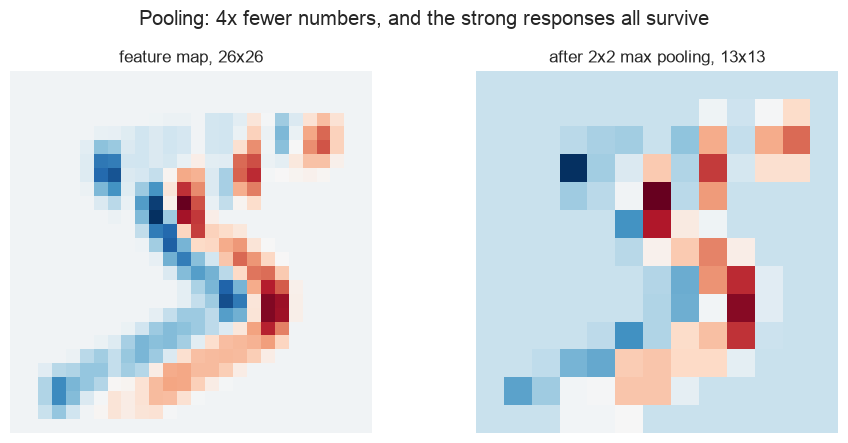

In [15]:
# Max-pool the vertical-edge feature map by hand: 26x26 -> 13x13.
pooled = np.zeros((13, 13))
for i in range(13):
    for j in range(13):
        block = feature_map[2 * i:2 * i + 2, 2 * j:2 * j + 2]   # one 2x2 block
        pooled[i, j] = block.max()                              # keep the strongest response

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.5))
axes[0].imshow(feature_map, cmap="RdBu_r")
axes[0].set_title("feature map, 26x26")
axes[0].axis("off")
axes[1].imshow(pooled, cmap="RdBu_r")
axes[1].set_title("after 2x2 max pooling, 13x13")
axes[1].axis("off")
fig.suptitle("Pooling: 4x fewer numbers, and the strong responses all survive")
plt.tight_layout()
plt.show()

## 7. Build the CNN

Now let PyTorch do the sliding — and, crucially, let it **learn the filter weights** instead of us hand-designing them. Stack up: convolve → ReLU → pool, twice, then flatten and one linear layer to get 10 scores. That's a **convolutional neural network** (CNN). New pieces:

- `nn.Conv2d(1, 8, kernel_size=3, padding=1)` — from 1 input **channel** (grayscale) make 8 output channels: **8 different learnable 3×3 filters**, each producing its own feature map. `padding=1` adds a 1-pixel border of zeros so the output stays 28×28 instead of shrinking to 26×26.
- `nn.MaxPool2d(2)` — the 2×2 max pooling from section 6.
- `nn.Flatten()` — the reshape-to-flat step, as a layer.

`Conv2d` expects images shaped `(batch, channels, height, width)`, so we insert a channel dimension with `.unsqueeze(1)`: `(n, 28, 28)` becomes `(n, 1, 28, 28)`.

Watch the shape after every layer: width and height shrink (28 → 14 → 7) while channels — parallel motif detectors — grow (1 → 8 → 16). The second conv layer sees the first layer's maps, so it detects *combinations of motifs*: corners, loops, stroke-endings.

In [16]:
cnn = nn.Sequential(
    nn.Conv2d(1, 8, kernel_size=3, padding=1),    # 1 channel in -> 8 learnable filters
    nn.ReLU(),
    nn.MaxPool2d(2),                              # 28x28 -> 14x14
    nn.Conv2d(8, 16, kernel_size=3, padding=1),   # 8 channels in -> 16 motif-combination detectors
    nn.ReLU(),
    nn.MaxPool2d(2),                              # 14x14 -> 7x7
    nn.Flatten(),                                 # 16 maps of 7x7 -> one row of 784 numbers
    nn.Linear(16 * 7 * 7, 10),                    # -> 10 digit scores
)

# Insert the channel dimension: (n, 28, 28) -> (n, 1, 28, 28).
X_train_img = X_train_t.unsqueeze(1)
X_test_img = X_test_t.unsqueeze(1)

# Push a batch of 4 images through ONE LAYER AT A TIME, printing the shape
# after each -- the single most useful debugging habit in deep learning.
x = X_train_img[:4]
print("input               ", tuple(x.shape))
for layer in cnn:
    x = layer(x)                            # apply just this one layer
    name = layer.__class__.__name__         # the layer's type name, e.g. 'Conv2d'
    # :<10 pads the name to 10 characters so the shapes line up.
    print(f"after {name:<10}    ", tuple(x.shape))

input                (4, 1, 28, 28)
after Conv2d         (4, 8, 28, 28)
after ReLU           (4, 8, 28, 28)
after MaxPool2d      (4, 8, 14, 14)
after Conv2d         (4, 16, 14, 14)
after ReLU           (4, 16, 14, 14)
after MaxPool2d      (4, 16, 7, 7)
after Flatten        (4, 784)
after Linear         (4, 10)


## 8. Train it — and count the parameters

Here's the payoff of writing `train_model` generically: it never assumed what shape the input is or what the model looks like inside. Same loop, new architecture.

In [17]:
print("training the CNN...")   # ~10 seconds: convolutions cost more per image
train_model(cnn, X_train_img, y_train_t, n_epochs=8)

cnn_accuracy = accuracy(cnn, X_test_img, y_test_t)
print(f"CNN test accuracy: {cnn_accuracy:.3f}   (the MLP got {mlp_accuracy:.3f})")

training the CNN...


  epoch 1: last batch loss = 0.475


  epoch 2: last batch loss = 0.069


  epoch 3: last batch loss = 0.035


  epoch 4: last batch loss = 0.026


  epoch 5: last batch loss = 0.163


  epoch 6: last batch loss = 0.045


  epoch 7: last batch loss = 0.124


  epoch 8: last batch loss = 0.018
CNN test accuracy: 0.976   (the MLP got 0.959)


In [18]:
def count_parameters(model):
    """Total number of learnable weights in a model."""
    total = 0
    for p in model.parameters():    # every weight matrix and bias vector in turn
        total = total + p.numel()   # numel = number of elements in the tensor
    return total

print("MLP parameters:", count_parameters(mlp))
print("CNN parameters:", count_parameters(cnn))
print()

# And the section-4 shift test, now for both models:
X_test_shifted_img = torch.tensor(X_test_shifted, dtype=torch.float32).unsqueeze(1) / 255.0
print(f"shifted-digits accuracy -- MLP: {accuracy(mlp, X_test_shifted_flat, y_test_t):.3f}"
      f"   CNN: {accuracy(cnn, X_test_shifted_img, y_test_t):.3f}")

MLP parameters: 101770
CNN parameters: 9098



shifted-digits accuracy -- MLP: 0.471   CNN: 0.743


Read that twice: the CNN is about **ten times smaller** than the MLP, *more accurate*, and far more tolerant of the shift that broke the MLP. That's what building the right assumption into the architecture buys you — "look for local motifs, and look for them everywhere" matches how images actually work, the way a well-designed primer matches its template.

## 9. Look inside the trained network

We never told the CNN what motifs to use — it *learned* its 8 first-layer filters from the data, the way evolution discovers motifs rather than being handed them. Let's look at what it chose, then push one real digit through and watch it turn into feature maps.

filter array shape: (8, 1, 3, 3)


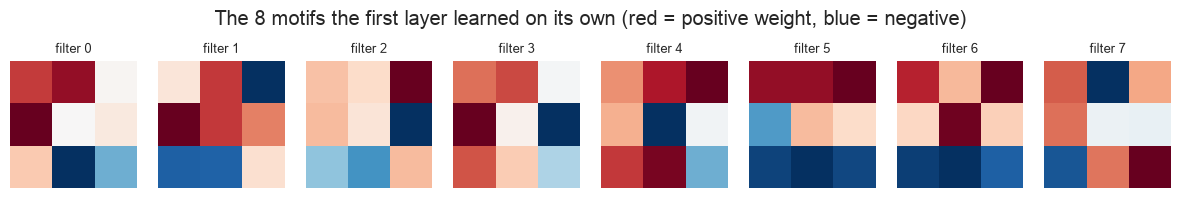

In [19]:
first_conv = cnn[0]     # the layers of a Sequential can be indexed like a list

# .detach() drops gradient tracking so we can convert weights to NumPy for plotting.
filters = first_conv.weight.detach().numpy()
print("filter array shape:", filters.shape)   # (8, 1, 3, 3): 8 filters, 1 input channel, 3x3 each

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for k in range(8):
    axes[k].imshow(filters[k, 0], cmap="RdBu_r")   # filter k, input channel 0
    axes[k].set_title(f"filter {k}", fontsize=9)
    axes[k].axis("off")
fig.suptitle("The 8 motifs the first layer learned on its own (red = positive weight, blue = negative)")
plt.tight_layout()
plt.show()

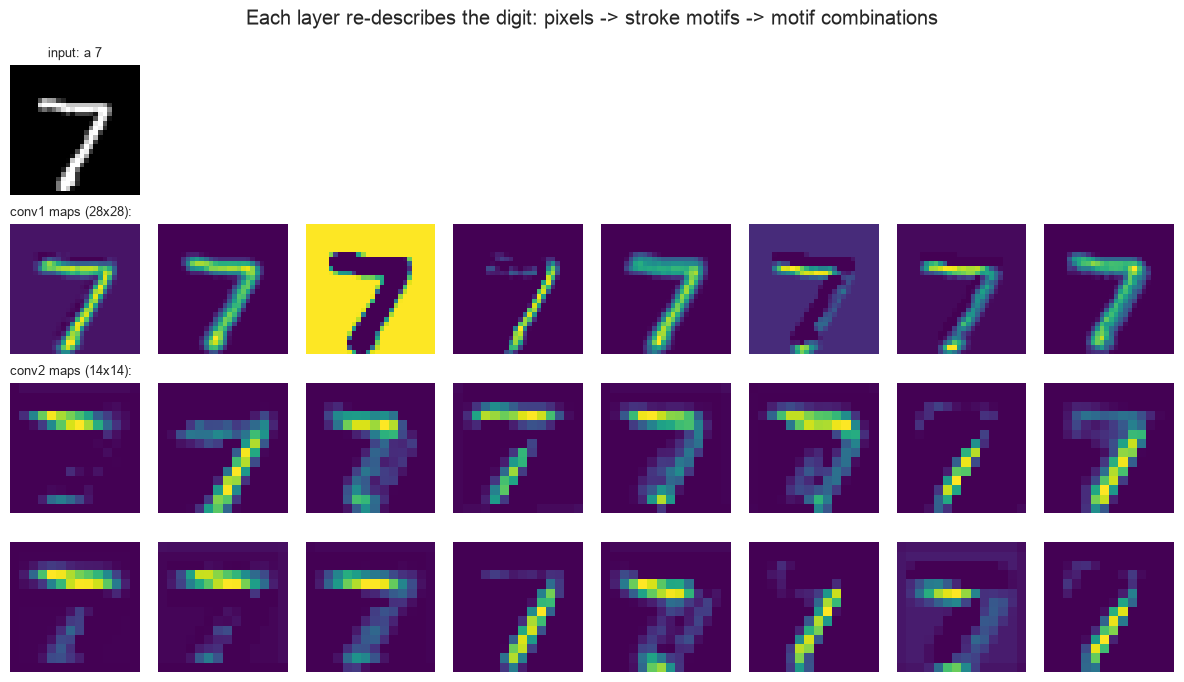

In [20]:
# Push ONE test digit through the first few layers and capture the feature maps.
x = X_test_img[0:1]      # slice 0:1 keeps the batch dimension: shape (1, 1, 28, 28)

with torch.no_grad():
    after_conv1 = torch.relu(cnn[0](x)).numpy()   # conv1 + ReLU: (1, 8, 28, 28)
    pooled1 = cnn[2](torch.relu(cnn[0](x)))       # then pool:    (1, 8, 14, 14)
    after_conv2 = torch.relu(cnn[3](pooled1)).numpy()   # conv2 + ReLU: (1, 16, 14, 14)

fig, axes = plt.subplots(4, 8, figsize=(12, 7))
# Row 0: the input digit in the first panel; the rest of the row stays empty.
for k in range(8):
    axes[0, k].axis("off")
axes[0, 0].imshow(X_test[0], cmap="gray")
axes[0, 0].set_title(f"input: a {y_test[0]}", fontsize=9)

# Row 1: the 8 feature maps after conv1 -- edge/stroke motifs.
for k in range(8):
    axes[1, k].imshow(after_conv1[0, k], cmap="viridis")
    axes[1, k].axis("off")
axes[1, 0].set_title("conv1 maps (28x28):", fontsize=9, loc="left")

# Rows 2-3: the 16 feature maps after conv2 -- combinations of motifs.
for k in range(16):
    row = 2 + k // 8       # first 8 maps on row 2, next 8 on row 3
    col = k % 8
    axes[row, col].imshow(after_conv2[0, k], cmap="viridis")
    axes[row, col].axis("off")
axes[2, 0].set_title("conv2 maps (14x14):", fontsize=9, loc="left")

fig.suptitle("Each layer re-describes the digit: pixels -> stroke motifs -> motif combinations")
plt.tight_layout()
plt.show()

Bright pixels in a feature map mean "my motif is here." Notice how different maps light up on different parts of the digit — one on the top bar, another on the curve — and how the conv2 maps are coarser and more abstract. By the final layer the network isn't looking at pixels anymore; it's looking at "loop at the top, straight stroke below," which is how *you* would describe a 9 to another person.

## 10. The confusion matrix: are its mistakes human?

Accuracy is one number; a **confusion matrix** is the full story — a 10×10 table counting every (true digit, predicted digit) pair in the test set. The diagonal is the correct calls; everything off the diagonal is a specific *kind* of mistake.

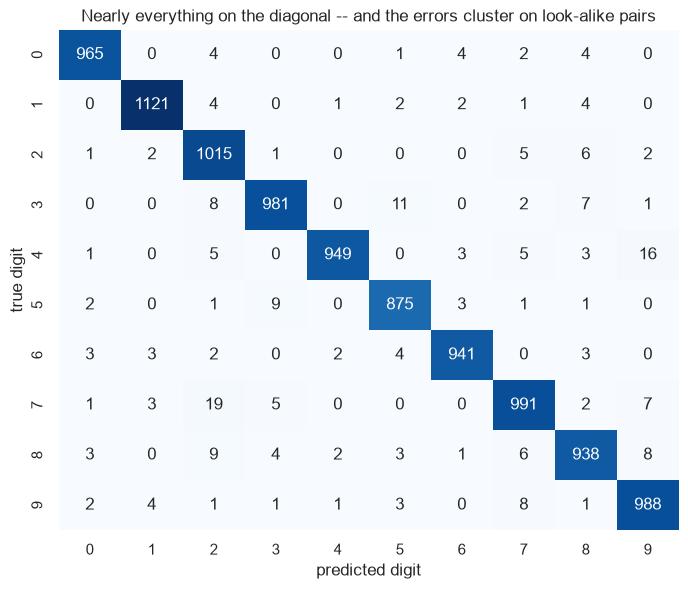

In [21]:
from sklearn.metrics import confusion_matrix   # counts every (true, predicted) pair

with torch.no_grad():
    test_scores = cnn(X_test_img)
    test_predictions = test_scores.argmax(dim=1).numpy()   # predicted digit per image

cm = confusion_matrix(y_test, test_predictions)

fig, ax = plt.subplots(figsize=(8, 6.5))
# annot=True writes the count inside each cell; fmt='d' formats them as integers.
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_xlabel("predicted digit")
ax.set_ylabel("true digit")
ax.set_title("Nearly everything on the diagonal -- and the errors cluster on look-alike pairs")
plt.show()

mistakes: 236 out of 10000 test digits


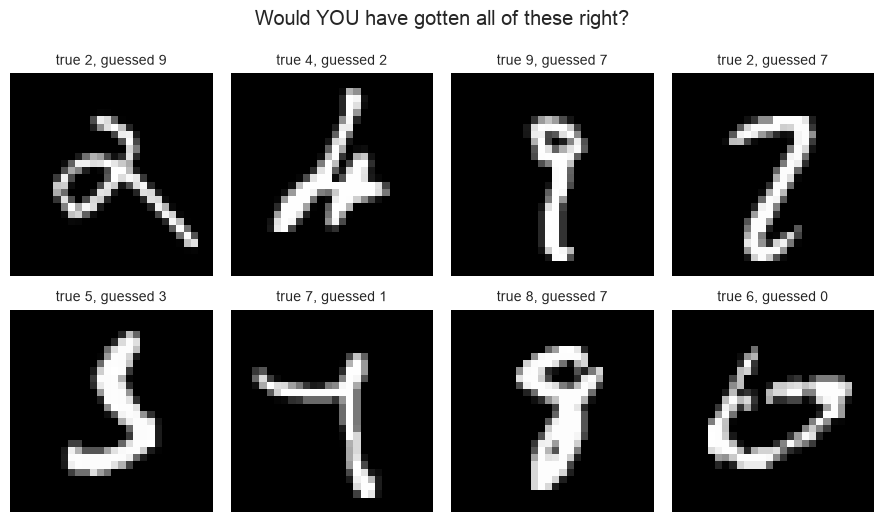

In [22]:
# Collect the row numbers of every test digit the CNN got wrong...
wrong = []
for i in range(len(y_test)):
    if test_predictions[i] != y_test[i]:
        wrong.append(i)
print("mistakes:", len(wrong), "out of", len(y_test), "test digits")

# ...and look at the first 8. ALWAYS look at your model's mistakes -- with
# malaria slides this step is where the biologist earns their keep.
fig, axes = plt.subplots(2, 4, figsize=(9, 5.5))
for k in range(8):
    row = k // 4
    col = k % 4
    idx = wrong[k]
    axes[row, col].imshow(X_test[idx], cmap="gray")
    axes[row, col].set_title(f"true {y_test[idx]}, guessed {test_predictions[idx]}", fontsize=10)
    axes[row, col].axis("off")
fig.suptitle("Would YOU have gotten all of these right?")
plt.tight_layout()
plt.show()

Check the biggest off-diagonal cells: they're almost always look-alike pairs — 4↔9, 3↔5, 7↔2, 8↔5. The machine's mistakes are largely the mistakes a tired human makes, which is reassuring: it's failing on genuinely ambiguous handwriting, not on some alien criterion.

## 11. Overfitting and dropout

With 10,000 training images our CNN had plenty to eat. Starve it — say, 1,000 images — and train long, and it will do what every over-flexible model does with too little data (Module 07): **overfit**, memorizing the training examples instead of learning the general pattern. The signature is a growing gap: training accuracy near 100%, test accuracy stuck lower.

The standard medicine is **dropout**: during training, randomly silence a fraction of the neurons — a different random subset at every step. It's a knockout experiment run continuously: because any neuron might be missing at any moment, the network can't let one neuron become a single point of failure, so knowledge gets distributed redundantly — the way essential genome functions are often backed up by paralogs. At test time all neurons are active again.

Two new method calls: `model.train()` switches dropout ON (training mode), `model.eval()` switches it OFF (evaluation mode). Let's run the experiment: same architecture, same 1,000 images, 30 epochs, with and without dropout.

In [23]:
def make_cnn(dropout_probability):
    """Our small CNN, optionally with a dropout layer before the final linear layer."""
    torch.manual_seed(42)          # identical starting weights -> a fair comparison
    layers = []
    layers.append(nn.Conv2d(1, 8, kernel_size=3, padding=1))
    layers.append(nn.ReLU())
    layers.append(nn.MaxPool2d(2))
    layers.append(nn.Conv2d(8, 16, kernel_size=3, padding=1))
    layers.append(nn.ReLU())
    layers.append(nn.MaxPool2d(2))
    layers.append(nn.Flatten())
    if dropout_probability > 0:
        # Dropout(0.5): during training, silence each incoming neuron with
        # probability 0.5 -- a fresh random subset at every training step.
        layers.append(nn.Dropout(dropout_probability))
    layers.append(nn.Linear(16 * 7 * 7, 10))
    # The * hands the list items to Sequential one by one, as separate arguments.
    return nn.Sequential(*layers)


X_small = X_train_img[:1000]       # starvation diet: only 1,000 training images
y_small = y_train_t[:1000]


def train_and_track(model, n_epochs):
    """Train on the small set, recording train AND test accuracy after each epoch."""
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    train_history = []
    test_history = []
    for epoch in range(n_epochs):
        model.train()                            # training mode: dropout ON
        shuffled = torch.randperm(len(X_small))
        # smaller batches (32) = more weight updates per epoch, so the starved
        # network gets every chance to memorize -- which is the point of the demo.
        for start in range(0, len(X_small), 32):
            batch = shuffled[start:start + 32]
            scores = model(X_small[batch])
            loss = loss_fn(scores, y_small[batch])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        model.eval()                             # evaluation mode: dropout OFF
        train_history.append(accuracy(model, X_small, y_small))
        test_history.append(accuracy(model, X_test_img, y_test_t))
    return train_history, test_history


plain_cnn = make_cnn(0.0)          # no dropout
dropout_cnn = make_cnn(0.5)        # 50% dropout

print("training WITHOUT dropout on 1,000 images...")   # ~6 s each: 30 short epochs
plain_train, plain_test = train_and_track(plain_cnn, n_epochs=30)
print("training WITH dropout on 1,000 images...")
drop_train, drop_test = train_and_track(dropout_cnn, n_epochs=30)

print(f"final train/test accuracy -- no dropout: {plain_train[-1]:.3f} / {plain_test[-1]:.3f}")
print(f"final train/test accuracy -- dropout:    {drop_train[-1]:.3f} / {drop_test[-1]:.3f}")

training WITHOUT dropout on 1,000 images...


training WITH dropout on 1,000 images...


final train/test accuracy -- no dropout: 1.000 / 0.924
final train/test accuracy -- dropout:    0.981 / 0.928


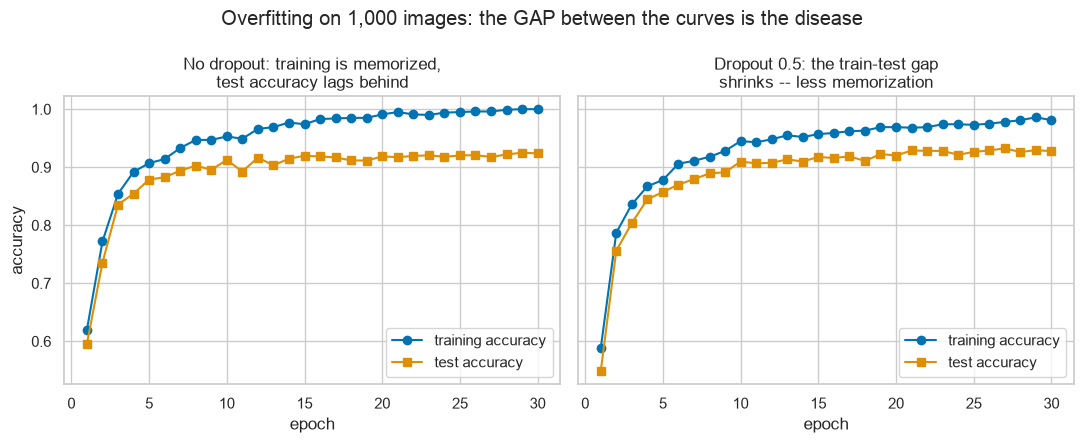

In [24]:
epochs = range(1, 31)              # epoch numbers 1..30 for the x-axis

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
axes[0].plot(epochs, plain_train, marker="o", label="training accuracy")
axes[0].plot(epochs, plain_test, marker="s", label="test accuracy")
axes[0].set_title("No dropout: training is memorized,\ntest accuracy lags behind")
axes[1].plot(epochs, drop_train, marker="o", label="training accuracy")
axes[1].plot(epochs, drop_test, marker="s", label="test accuracy")
axes[1].set_title("Dropout 0.5: the train-test gap\nshrinks -- less memorization")
for ax in axes:
    ax.set_xlabel("epoch")
    ax.legend()
axes[0].set_ylabel("accuracy")
fig.suptitle("Overfitting on 1,000 images: the GAP between the curves is the disease")
plt.tight_layout()
plt.show()

Honest reading: the striking symptom is the **gap** — without dropout, training accuracy races to ~100% (pure memorization: with only 1,000 examples the network can simply remember each one) while test accuracy plateaus well below. Dropout narrows that gap and usually buys a modest test improvement — it's medicine, not magic. The stronger cures are boring and biological in spirit: **more data**, or a smaller model. That's why we could train on 10,000 images all along without worrying much.

## 12. Where next: real disease diagnosis

Take stock of what you built today, because it's the entire modern computer-vision toolkit in miniature:

- images are grids of numbers, normalized to 0–1;
- flattening throws away neighborhoods — the MLP's blind spot;
- **convolution** = one learned motif detector scanned everywhere (a restriction enzyme for pixels), **pooling** = keep the strongest local response;
- a small CNN beat a 10×-bigger MLP *because its architecture matches how images work*;
- feature maps and the confusion matrix let you look inside and audit the mistakes;
- dropout (plus more data) keeps a starved network from memorizing.

The fruit-fly work is done. Next stop is the mouse: the **capstone project** — 27,558 real microscope photos of single red blood cells from hospital patients in Bangladesh, half of them parasitized with *Plasmodium*. Same pixels-in, scores-out machinery, but the two classes are "healthy" and "infected," and the confusion matrix becomes a diagnostic question: which error is worse in a rural clinic? See the capstone section of the [curriculum](../../docs/curriculum.md) — you now know everything the malaria detector needs.